# Explore Steam Games Metacritic Scores

__Goal:__ Explore which Steam game characteristics are associated with higher Metacritic scores. The scores are split into 4 categories for simplicity.

_Note:_ Analysis excludes games without Metacritic scores.

_Note 2:_ This notebook was created for learning purposes. 
The analysis is exploratory rather than interded to form definitive business conclusions.

In [1]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# Load data
df = pd.read_csv("games_scored.csv")
df.head()

,name,estimated_owners,required_age,About the game,language_support,Windows,Mac,Linux,metacritic_category,Metacritic score,Genres,price,price_category,release_year
0,🔴 Circles,0 - 20000,0,"Circles is a unique, intuitive puzzle game whe...","['English', 'French', 'Italian', 'German', 'Sp...",True,True,False,Good (76-85),76,"Casual,Indie",0.00,Free,2017
1,Franchise Hockey Manager 3,0 - 20000,0,"Franchise Hockey Manager 3 is the deepest, mos...",['English'],True,True,False,Average (61-75),64,"Indie,Simulation,Sports,Strategy",19.99,5-20,2016
2,REZ PLZ,0 - 20000,0,"Human Sacrifices, Very Poor Magic and More! Jo...","['English', 'French', 'German', 'Spanish - Spa...",True,False,False,Average (61-75),75,"Action,Adventure,Indie",2.99,0-5,2020
3,Trailblazers,0 - 20000,0,Welcome to the Trailblaze Tournament! Get read...,"['English', 'French', 'Italian', 'German', 'Sp...",True,True,True,Average (61-75),69,"Action,Casual,Indie,Racing,Sports",1.49,0-5,2018
4,Simon the Sorcerer Origins,0 - 20000,0,A New Journey Begins! Thirty years after his f...,"['English', 'French', 'Italian', 'German', 'Sp...",True,True,True,Good (76-85),76,Adventure,19.99,5-20,2025


In [3]:
# Check for duplicate names

# How many duplicate rows
print("Duplicate rows: "+str(df["name"].duplicated().sum()))

# How many game names have duplicates
print("Duplicate games: "+str((df["name"].value_counts() > 1).sum()))

# Which games have duplicates
duplicates = df[
    df["name"].duplicated(keep=False)
].sort_values("name")
duplicates[["name"]].drop_duplicates()

# Drop duplicates
df = df.drop_duplicates(subset="name")

Duplicate rows: 65
Duplicate games: 43


In [4]:
# Statistics by metacritic category

# Helper: mode that safely returns one value
def get_mode(series):
    mode_values = series.dropna().mode()
    return mode_values.iloc[0] if len(mode_values) > 0 else None

stats_by_metacritic = (
    df
    .groupby("metacritic_category")
    .agg(
        games=("name", "count"),
        mean_required_age=("required_age", "mean"),
        mode_estimated_owners=("estimated_owners", get_mode),
        mean_price=("price", "mean"),
        mean_release_year=("release_year", "mean")
    )
    .reset_index()
)

stats_by_metacritic["share_of_games"] = (
    stats_by_metacritic["games"] / stats_by_metacritic["games"].sum() * 100
).round(1)


In [5]:
# Table of statistics by metacritic category

table = stats_by_metacritic[[
    "metacritic_category",
    "games",
    "share_of_games",
    "mean_price",
    "mean_release_year",
    "mean_required_age",
    "mode_estimated_owners"
]].copy()

# Order categories
category_order = ["Excellent (86-100)", "Good (76-85)", "Average (61-75)", "Low (1-60)"]

table["metacritic_category"] = pd.Categorical(
    table["metacritic_category"],
    categories=category_order,
    ordered=True
)

table = table.sort_values("metacritic_category")

fig = go.Figure(data=[go.Table(
    header=dict(
        values=[
            "Metacritic Category",
            "Games",
            "Share %",
            "Price, average",
            "Release year, average",
            "Age requirement, average",
            "Estimated owners, mode"
        ]
    ),
    cells=dict(
        values=[table[col] for col in table.columns],
        format=[None, ".0f",".0f", ".1f", ".1f", ".1f", None]
    )
)])

fig.update_layout(
    height=200,
    margin=dict(l=10, r=10, t=40, b=10)
)
fig.show()

In [6]:
# Keep only rows with a common age requirement

valid_ages = (
    df["required_age"]
    .value_counts()
    .loc[lambda x: x >= 10]
    .index
)

df_filtered = df[
    df["required_age"].isin(valid_ages)
].copy()

In [7]:
# Visualizations
# Required age as a grouped histogram. Metacritic category as colour.

# Join small categories
df_filtered["required_age_grouped"] = (
    df_filtered["required_age"]
    .replace({18: "16+", 17: "16+", 16: "16+"})
    .astype(str)
)

category_order = [
    "Excellent (86-100)",
    "Good (76-85)",
    "Average (61-75)",
    "Low (1-60)"
]

age_order = ["0", "13", "16+"]

category_colors = {
    "Excellent (86-100)": "#00cc66",
    "Good (76-85)": "#99e699",
    "Average (61-75)": "#d9c9a3",
    "Low (1-60)": "#b3b3b3"
}

fig = px.histogram(
    df_filtered,
    x="required_age_grouped",
    color="metacritic_category",
    barmode="group",
    histnorm="percent",
    category_orders={
        "metacritic_category": category_order,
        "required_age_grouped": age_order
    },
    color_discrete_map=category_colors,
    title="Required Age Distribution by Metacritic Category"
)

fig.update_layout(
    yaxis_title="Share of category (%)",
    xaxis_title="Required Age"
)

fig.show()

In [8]:
# Estimated owners distribution by Metacritic category

owner_order = [
    "0 - 20000",
    "20000 - 50000",
    "50000 - 100000",
    "100000 - 200000",
    "200000 - 500000",
    "500000 - 1000000",
    "1000000 - 2000000",
    "2000000 - 5000000",
    "5000000 - 10000000",
    "10000000 - 20000000",
    "20000000 - 50000000",
    "50000000 - 100000000"
]

fig = px.histogram(
    df_filtered,
    x="estimated_owners",
    color="metacritic_category",
    barmode="group",
    histnorm="percent",
    category_orders={
        "estimated_owners": owner_order,
        "metacritic_category": category_order
    },
    color_discrete_map=category_colors,
    title="Estimated Owners Distribution by Metacritic Category"
)

fig.update_layout(
    yaxis_title="Share of category (%)",
    xaxis_title="Estimated Owners"
)

fig.show()

In [9]:
# Check release year frequencies
df_filtered["release_year"].value_counts().sort_index()

release_year
1997      1
1998      1
2000      1
2001      2
2002      1
2003      1
2004      3
2005      5
2006     36
2007     63
2008     89
2009    162
2010    123
2011    161
2012    179
2013    228
2014    329
2015    341
2016    355
2017    319
2018    313
2019    261
2020    283
2021    236
2022    160
2023    187
2024    174
2025    142
Name: count, dtype: int64

In [10]:
# Let's keep games released since 2009
df_year_filtered = df_filtered[
    df_filtered["release_year"]>2009
].copy()

In [11]:
# Plot Share of Metacritic categories by year

yearly_scores = (
    df_year_filtered
    .groupby(["release_year", "metacritic_category"])
    .size()
    .reset_index(name="games")
)

# Convert to percentages within each year
yearly_scores["share"] = (
    yearly_scores["games"]
    / yearly_scores.groupby("release_year")["games"].transform("sum")
    * 100
)

fig = px.bar(
    yearly_scores,
    x="release_year",
    y="share",
    color="metacritic_category",
    category_orders={
        "metacritic_category": category_order
    },
    color_discrete_map=category_colors,
    title="Share of Metacritic Categories by Release Year"
)

fig.update_layout(
    barmode="stack",
    yaxis_title="Share of games (%)",
    xaxis_title="Release Year"
)

fig.show()

The share of good/excellent games has increased in the recent years. This indicates a possible bias in the data.

In [12]:
# Check top 20 genres in filtered df
genres = df_year_filtered["Genres"].dropna().str.split(",")
all_genres = genres.explode().str.strip()
all_genres = all_genres[all_genres != "Free To Play"]
all_genres.value_counts().head(10)

Genres
Indie                    2300
Adventure                1890
Action                   1889
Strategy                  925
RPG                       883
Simulation                615
Casual                    551
Sports                    110
Racing                    110
Massively Multiplayer      72
Name: count, dtype: int64

In [13]:
# Turning variables numeric for k-means clustering

# Select variables
df_numeric= df_year_filtered[[
    "estimated_owners",
    "required_age",
    "metacritic_category",
    "Genres",
    "price_category",
    "release_year"
]].copy()

# One-hot encode common categories (exclude free-to-play)
top_genres = [
    "Indie",
    "Action",
    "Adventure",
    "Strategy",
    "RPG",
    "Simulation",
    "Casual",
    "Racing",
    "Sports",
    "Massively Multiplayer"
]

# Columns named genre_indie
# 1 = game is this genre, 0 = not this genre

for genre in top_genres:
    column_name = f"genre_{genre.lower().replace(' ', '_')}"

    df_numeric[column_name] = (
        df_numeric["Genres"]
        .fillna("")
        .str.contains(genre, case=False)
        .astype(int)
    )

# Drop original genre column
df_numeric = df_numeric.drop(columns=["Genres"])

df_numeric.head()


,estimated_owners,required_age,metacritic_category,price_category,release_year,genre_indie,genre_action,genre_adventure,genre_strategy,genre_rpg,genre_simulation,genre_casual,genre_racing,genre_sports,genre_massively_multiplayer
0,0 - 20000,0,Good (76-85),Free,2017,1,0,0,0,0,0,1,0,0,0
1,0 - 20000,0,Average (61-75),5-20,2016,1,0,0,1,0,1,0,0,1,0
2,0 - 20000,0,Average (61-75),0-5,2020,1,1,1,0,0,0,0,0,0,0
3,0 - 20000,0,Average (61-75),0-5,2018,1,1,0,0,0,0,1,1,1,0
4,0 - 20000,0,Good (76-85),5-20,2025,0,0,1,0,0,0,0,0,0,0


In [14]:
# Owners category, metacritic category, price category into numeric

owners_map = {
    "0 - 20000": 1,
    "20000 - 50000": 2,
    "50000 - 100000": 3,
    "100000 - 200000": 4,
    "200000 - 500000": 5,
    "500000 - 1000000": 6,
    "1000000 - 2000000": 7,
    "2000000 - 5000000": 8,
    "5000000 - 10000000": 9,
    "10000000 - 20000000": 10,
    "20000000 - 50000000": 11,
    "50000000 - 100000000": 12,
    "100000000 - 200000000": 13
}

metacritic_map = {
    "Low (1-60)": 1,
    "Average (61-75)": 2,
    "Good (76-85)": 3,
    "Excellent (86-100)": 4
}

price_map = {
    "Free": 0,
    "0-5": 1,
    "5-20": 2,
    "20+": 3
}

df_numeric = df_numeric.copy()
df_numeric["estimated_owners_num"] = df_numeric["estimated_owners"].map(owners_map)
df_numeric["metacritic_num"] = df_numeric["metacritic_category"].map(metacritic_map)
df_numeric["price_num"] = df_numeric["price_category"].map(price_map)

df_numeric = df_numeric.drop(
    columns=["estimated_owners", "metacritic_category", "price_category"]
)
df_numeric.head()

,required_age,release_year,genre_indie,genre_action,genre_adventure,genre_strategy,genre_rpg,genre_simulation,genre_casual,genre_racing,genre_sports,genre_massively_multiplayer,estimated_owners_num,metacritic_num,price_num
0,0,2017,1,0,0,0,0,0,1,0,0,0,1,3,0
1,0,2016,1,0,0,1,0,1,0,0,1,0,1,2,2
2,0,2020,1,1,1,0,0,0,0,0,0,0,1,2,1
3,0,2018,1,1,0,0,0,0,1,1,1,0,1,2,1
4,0,2025,0,0,1,0,0,0,0,0,0,0,1,3,2


## Clustering
K-Means clustering is used for exploratory analysis. It is not expected to find very distinct segments.

PCA is used for visualization purposes only.

In [15]:
# Scale numeric features
scaler = StandardScaler()

scaled_array = scaler.fit_transform(df_numeric)

df_scaled = pd.DataFrame(
    scaled_array,
    columns=df_numeric.columns,
    index=df_numeric.index
)

In [16]:
# K-means clustering

#Initialize the class object
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(df_scaled)

In [ ]:
# Explore the cluster means to find explanations for the segments

df_numeric["cluster"] = clusters

cluster_summary = (
    df_numeric
    .groupby("cluster")
    .mean(numeric_only=True)
    .round(2)
)

cluster_sizes = (
    df_numeric["cluster"]
    .value_counts()
    .sort_index()
)

cluster_summary.insert(
    0,
    "cluster_size",
    cluster_sizes
)

cluster_summary

,cluster_size,required_age,release_year,genre_indie,genre_action,genre_adventure,genre_strategy,genre_rpg,genre_simulation,genre_casual,genre_racing,genre_sports,genre_massively_multiplayer,estimated_owners_num,metacritic_num,price_num
cluster,,,,,,,,,,,,,,,,
0,72,1.12,2015.93,0.33,0.72,0.46,0.31,0.64,0.22,0.12,0.03,0.04,1.0,6.47,2.50,0.49
1,1103,5.12,2016.16,0.07,0.64,0.34,0.28,0.26,0.01,0.03,0.03,0.02,0.0,5.31,2.56,1.45
2,2011,0.16,2017.82,0.92,0.49,0.65,0.15,0.22,0.00,0.19,0.02,0.01,0.0,3.39,2.44,1.39
3,605,0.24,2018.01,0.57,0.24,0.28,0.49,0.19,0.98,0.23,0.07,0.10,0.0,4.43,2.38,1.47


In [18]:
# Heatmap for quick visual interpretation
# Mean feature values by cluster (scaled data)
cluster_profiles = (
    df_scaled
    .groupby(clusters)
    .mean()
    .round(2)
)

fig = px.imshow(
    cluster_profiles,
    text_auto=True,
    aspect="auto",
    color_continuous_scale="RdYlGn",
    title="Cluster Feature Heatmap (Scaled Features)"
)

fig.update_layout(
    xaxis_title="Features",
    yaxis_title="Cluster"
)

fig.show()

### Cluster descriptions
- __Cluster 0:__ Small cluster, action, RPG, massively multiplayer, high estimated owners, low price. _"Massively multiplayer"_

- __Cluster 1:__ High age requirement, not-indie, not-casual, high metacritic score. _"Big games"_

- __Cluster 2:__ Big cluster, indie, adventure, low estimated owners. _"Indie adventure"_

- __Cluster 3:__ Strategy, simulation, racing. _"Strategic simulation"_

In [19]:
# Show 5 eaxample games of each group
df_numeric["name"] = df_year_filtered["name"]

representative_games = (
    df_numeric
    .groupby("cluster")["name"]
    .apply(lambda x: list(x.head(5)))
    .apply(pd.Series)
    .T
)

representative_games.columns = [
    f"cluster_{col}"
    for col in representative_games.columns
]

representative_games

,cluster_0,cluster_1,cluster_2,cluster_3
0,Guild Wars: Eye of the North®,Shadow of the Tomb Raider: Definitive Edition,🔴 Circles,Franchise Hockey Manager 3
1,ARCADE,Company of Heroes 2 - The Western Front Armies,REZ PLZ,Static Dread: The Lighthouse
2,The Elder Scrolls Online: Necrom,BRINK,Trailblazers,Snow Moto Racing Freedom
3,Ink,Koihime Enbu,Simon the Sorcerer Origins,Fuga: Melodies of Steel 3
4,Allods Online,The Dark Crystal: Age of Resistance Tactics,Indygo,Closer the Distance


In [20]:
# Use PCA to help with cluster visualization

# PCA in 2 dimensions
pca = PCA(n_components=2)

pca_components = pca.fit_transform(df_scaled)

# Create a dataframe for plotting
pca_df = pd.DataFrame(
    pca_components,
    columns=["PC1", "PC2"]
)

pca_df["cluster"] = clusters.astype(str)

# Centroids in PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)

centroids_df = pd.DataFrame(
    centroids_pca,
    columns=["PC1", "PC2"]
)

/opt/anaconda3/envs/llms_course_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


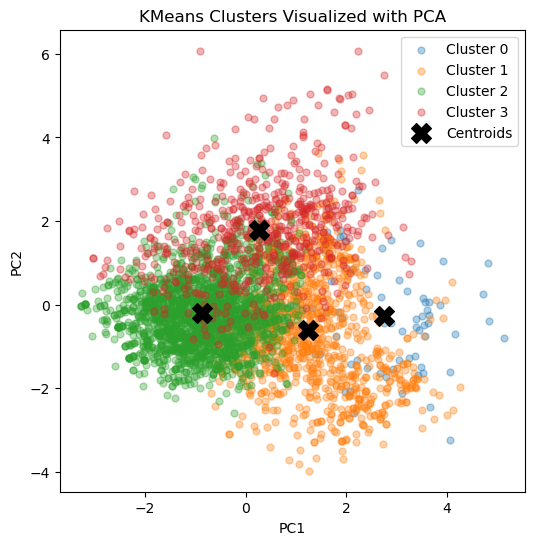

In [21]:
# Plot the K-means clusters using PCA dimensions

plt.figure(figsize=(6, 6))

# Plot points
for cluster in sorted(pca_df["cluster"].unique()):
    subset = pca_df[pca_df["cluster"] == cluster]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.35,
        s=25,
        zorder=1
    )

# Plot centroids on top
plt.scatter(
    centroids_df["PC1"],
    centroids_df["PC2"],
    color="black",
    marker="X",
    s=200,
    label="Centroids",
    zorder=10
)

plt.title("KMeans Clusters Visualized with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

The clusters are not well separated in PCA space.
This could be expected as there is no clear groups of the games, just more and less similar ones.
Ideas for future analysis:
- Feature engineering, add more variables
- Cluster amount optimization

In [22]:
# Show the importance of each variable in both PCA dimensions
pca_loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=df_scaled.columns
)
pca_loadings.style.format("{:.2f}").background_gradient(
    cmap="coolwarm",
    axis=None
)

,PC1,PC2
required_age,0.33,-0.33
release_year,-0.35,-0.12
genre_indie,-0.45,0.05
genre_action,0.11,-0.36
genre_adventure,-0.36,-0.32
genre_strategy,0.19,0.37
genre_rpg,0.09,-0.17
genre_simulation,0.09,0.42
genre_casual,-0.26,0.18
genre_racing,0.06,0.27


## Key takeaways
- Most games have a good or average Metacritic score, less games are rated low or excellent.

- There is a possible selection bias in the data, as the ratio of good/excellent games has increased in the recent years.

- Price, estimated owners and age requirement are typically higher in games with higher metacritic scores.

- The games can be separated into four clusters: massively multiplayer, large-scale games, indie adventure, and strategic simulation.

- The PCA visualization suggests that the clusters overlap, meaning the segments are directional and not clearly separated categories.